## EDA Basenotes acquired colognes


In [94]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [95]:
conn = sqlite3.connect("/Users/gauravkumar/Downloads/cologne-recommender/data/colognes_basenotes.db")

query = """
SELECT 
    c.id, 
    c.name, 
    c.brand, 
    c.gender, 
    c.positive_reviews, 
    c.neutral_reviews, 
    c.negative_reviews,
    c.review_texts,
    GROUP_CONCAT(n.name, ', ') AS fragrance_notes
FROM colognes c
LEFT JOIN cologne_notes cn ON c.id = cn.cologne_id
LEFT JOIN notes n ON cn.note_id = n.id
GROUP BY c.id
"""
df = pd.read_sql_query(query, conn)
display(df.sample(10))

,id,name,brand,gender,positive_reviews,neutral_reviews,negative_reviews,review_texts,fragrance_notes
453,454,French Lover / Bois d'Orage,Editions de Parfums Frederic Malle (2007),Unisex,62,15,12,"[""Green and woody, this one has some appeal to...","patchouli, cedarwood, galbanum, vetiver, incen..."
2039,2040,Shuhrah pour Homme,Rasasi (2015),Unisex,5,0,0,"[""Shuhrah pour Homme by Rasasi (2015) is prett...","jasmine, cedarwood, rose, oakmoss, amber, sand..."
3715,3716,Tease Crème Cloud,Victoria's Secret (2021),Male,1,0,0,"[""If this had better longevity, it would proba...","vanilla meringue, santal flower, sheer amber"
597,598,Bombshell,Victoria's Secret (2010),Male,3,1,0,"[""Have the perfume,body mist,lotion LOVE LOVE ...","vanilla orchid, peony, passion fruit"
1597,1598,Santal Majuscule,Serge Lutens (2012),Unisex,28,13,2,"[""rose, chocolate and sandalwood done in the t...","rose, sandalwood, tonka bean, cocoa, rosewood"
503,504,Epic Woman,"Eau de Parfum, Amouage (2009)",Unisex,16,6,1,"[""This is another win in the women\u2019s line...","pink pepper, jasmine, vanilla, orris, amber, s..."
2724,2725,No. 18,"Eau de Toilette, Chanel (2007)",Unisex,21,7,4,"[""To me, this is the best perfume from Chanel....","white musk, geranium, ambrette seed, Rose, Iri..."
292,293,Versace Man Eau Fraîche,"Eau de Toilette, Versace (2006)",Unisex,91,44,31,"[""According to Versace, depending upon where y...","amber, musk, lemon, rosewood, sage, tarragon, ..."
547,548,Ambre Russe,"Eau de Parfum, Parfum d'Empire (2005)",Unisex,54,8,3,"[""An amber for people who don't care for amber...","coriander, ambergris, cinnamon, cumin, russian..."
1280,1281,Champs-Elysées Too Much,Guerlain (2000),Unisex,5,1,0,"[""The Eau De Toilette, Champs-Elys\u00e9es, To...","jasmine, bergamot, hyacinth, woods, heliotrope..."


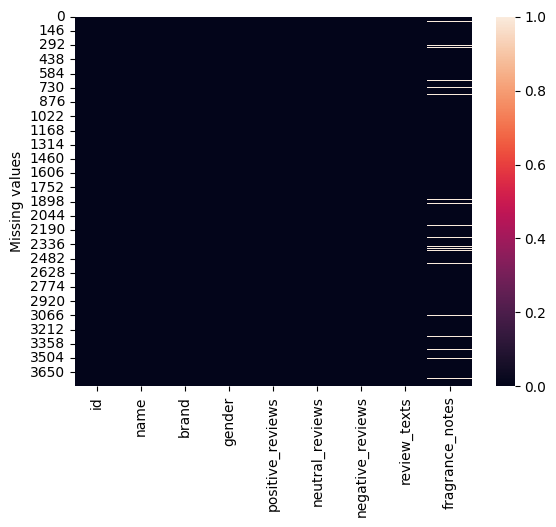

In [96]:
ax = plt.axes()
sns.heatmap(df.isna(), ax=ax)
plt.ylabel('Missing values')
plt.show()

In [97]:

df['fragrance_notes'].isna().sum()

np.int64(209)

In [98]:
(df['review_texts']== "[]").sum()

np.int64(328)

In [99]:
df['review_texts'] = df['review_texts'].mask(df['review_texts'].apply(lambda x:x == "[]"), np.nan)

In [100]:
df['review_texts'].isna().sum()

np.int64(328)

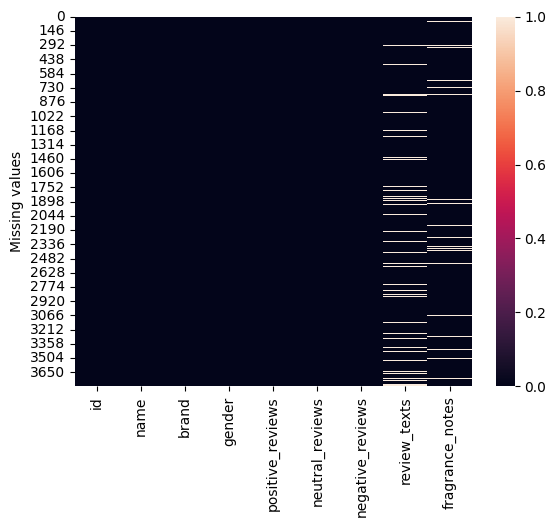

In [101]:
ax = plt.axes()
sns.heatmap(df.isna(), ax=ax)
plt.ylabel('Missing values')
plt.show()

In [102]:

df[df.isna().any(axis=1)].sample(5).style.highlight_null(color='red')

,id,name,brand,gender,positive_reviews,neutral_reviews,negative_reviews,review_texts,fragrance_notes
2267,2268,Exalté by Funmi Monet,Bella Aura × Funmi Monet (2022),Female,0,0,0,nan,"pink pepper, orange blossom, jasmine, vanilla, amber, sandalwood, musk, lemon, benzoin, turkish rose, osmanthus"
1710,1711,Captivatingly Paris,Zara (2022),Unisex,0,0,0,nan,"rose, musk, pear"
3556,3557,West Indian Limes,Truefitt & Hill (1870),Male,12,4,1,"[""Top: Citrus, lemon, lime, bergamot MId: Petitgrain, Neroli, Citronella Base: orange flower, clove This is a super-citrusy scent! The lemon notes really pop. Of course there's lime here as well. This is an extremely straight-forward scent -- it is entirely citrus based. I don't even really get the neroli or orange flower to a significant extent. This is the limitation of the scent. It smells good. It's lemony. That's about it. But I give it a thumbs up because it smells good."", ""I have a friend who's obsessed with spice drops. They're a candy, like gumdrops but with a pinch of clove to make them \""spicy\"". This smells exactly like a lemon spice drop - artificial and VERY sugary with a pinch of clove for spice. I can even smell that distinct corn syrup sweetness. If forced, I can pick out the lime, though I think the \""lime\"" is such an artificial odorant that it registers as lemon candy to me. Given time, civet musk arrives and overwhelms the sugar, at which point this smells like what I'd expect from an old-fashioned British lime cologne: fake lime bathroom cleaner in a gross stinky restroom. It's an odd combination, as I'd imagine that people who would love the candy topnotes would hate the old-school musky base, and vice versa. Personally, in a bad mood, I could easily write this off as both childish and gross, but in a good mood, this is a lot of fun. In the end, despite or because of the candy smell, this is one of the better old fashioned lime colognes that I've tried, so I'm voting thumbs up."", ""Overall a thumbs up. The scent - and I recognize this is subtle - is less limes and more limeade. I swear I can smell the lime juice and the sugar mixed in with it together in some kind of delicious, refreshing wearable. When you compare, for example, to the much less expensive but substantially longer-lasting scent of Pinaud Lime Sec (which I think one can smell equal parts lime zest and lime juice in), the West Indian Lime scent would be more \""artificial\"", but to my nose it isn't what I'd describe as \""synthetic\"". Still, I find myself wearing the Pinaud because it lasts well, and by comparison I've been told it smells very clean (if not very complex). Still, though, it smells good - again, exactly like the limeade you'd get from a vendor on a beach boardwalk in the summer. But the scent is, sadly, not very long-lasting. I'd suspect only someone standing close to me on the train is going to smell it at 9am, and by lunch nobody'd be the wiser; the scent is gone by then. The staying power is its primary drawback; at $75-$100 bottle, I'd like it last more than a couple of hours.""]",nan
2452,2453,G. Bellini No. 1,Lidl (2014),Unisex,1,0,0,"[""Very similar to Paco Rabanne 1 Million but at 10% of the price. Less longevity but definitely worth it.""]",nan
3347,3348,Malaia,Hollister (2005),Male,0,0,0,nan,"lavender, basil, vanilla bean"


<Axes: >

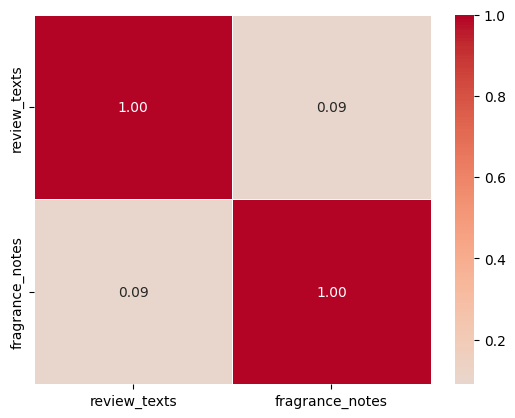

In [103]:
df_corr= df.isna().corr()
nan_cols = df.columns[df.isna().any()]
corr_mat = df_corr.loc[nan_cols, nan_cols]
sns.heatmap(corr_mat, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)


In [104]:
df['review_texts'].isna().corr(df['fragrance_notes'].isna()) # no correlation whatsoever

np.float64(0.09013855111272899)

In [105]:
(537/3639)*100

14.756801319043694

In [106]:
zero_neg_count = (df['negative_reviews'] == 0).sum()
print(f"Number of rows with zero negative reviews: {zero_neg_count}")
zero_pos_count = (df['positive_reviews'] == 0).sum()
print(f"Number of rows with zero positive reviews: {zero_pos_count}")
zero_neu_count = (df['neutral_reviews'] == 0).sum()
print(f"Number of rows with zero neutral reviews: {zero_neu_count}")
zero_all_count = (df['negative_reviews'] == 0) & (df['positive_reviews'] == 0) & (df['neutral_reviews'] == 0)
print(f"Number of rows with zero reviews: {zero_all_count.sum()}")


Number of rows with zero negative reviews: 1673
Number of rows with zero positive reviews: 472
Number of rows with zero neutral reviews: 1044
Number of rows with zero reviews: 328


In [107]:
reviews = ['positive_reviews', 'negative_reviews', 'neutral_reviews']
all_zero = (df[reviews] == 0).all(axis=1).sum()
unique_zero = (df[reviews] == 0).any(axis=1).sum()
print(f"Rows with all zeros: {all_zero}")
print(f"Rows with at least one zero: {unique_zero}")

Rows with all zeros: 328
Rows with at least one zero: 1910


In [108]:
df['review_texts'].isna().corr((df[reviews] == 0).all(axis=1))

np.float64(1.0)

In [109]:

df.dropna(subset=['review_texts'], inplace=True)

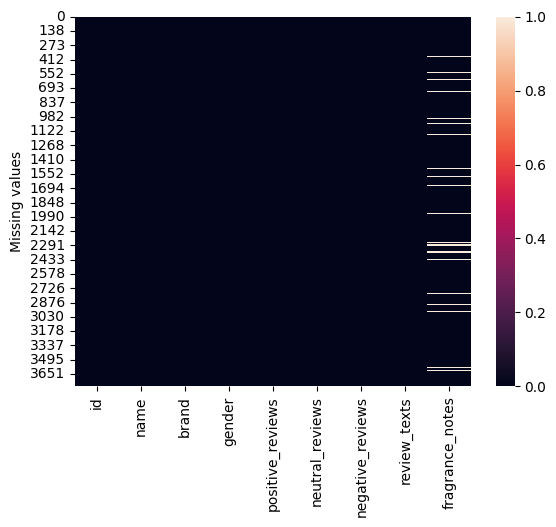

In [110]:
ax = plt.axes()
sns.heatmap(df.isna(), ax=ax)
plt.ylabel('Missing values')
plt.show()

In [111]:
df.dropna(subset=['fragrance_notes'], inplace=True)

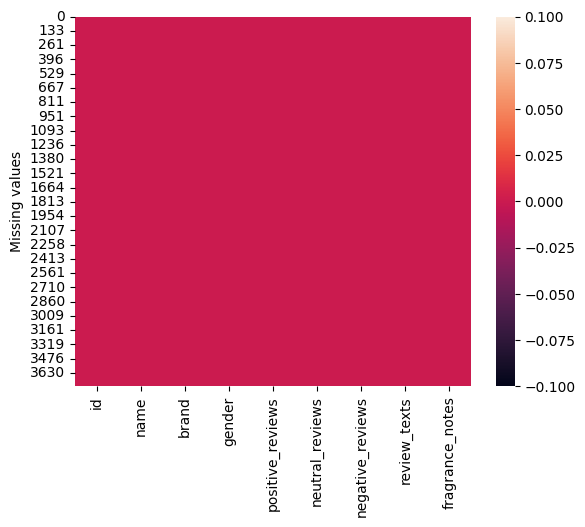

In [112]:
ax = plt.axes()
sns.heatmap(df.isna(), ax=ax)
plt.ylabel('Missing values')
plt.show()

In [113]:
df['review_texts']

0       ["I felt incredibly disappointed by this scent...
1       ["My wife is a lover of Chypre fragrances star...
2       ["What to say about this classic that hasn't a...
3       ["I knew I HAD to sample this after reading on...
4       ["Generic \"shower gel\" soap smell with terri...
                              ...                        
3788    ["It opens with a sweetness that consists of s...
3789    ["Just perfect! Happy and simple smell! My fra...
3790    ["Another day, another 60s green chypre. Where...
3791    ["The opening is a fruity affair, steamed peac...
3792    ["If I could give this a 3.5, rather than eith...
Name: review_texts, Length: 3296, dtype: str

In [143]:
#df_test = df['review_texts'].str.strip('[],""')


In [ ]:
#df_test.sample(10)

1719    I love this quote by Nathalie Feisthauer about...
3524    Fille d'Eve somehow feels both mirthful and ca...
2071    This is okay, but it's essentially the origina...
237     Very clean, strongly soapy white floral. Someb...
832     A fascinating crossroads between the 70s green...
2823    A really nice soft and refreshing citrus heavy...
1758    Back to the drawing board gents! The original ...
2561    As much as I like this I have to say performan...
3012    As a kid, I saw a bottle of this in one of my ...
1781    In The Guide II, genre is given as \"vanilla w...
Name: review_texts, dtype: str

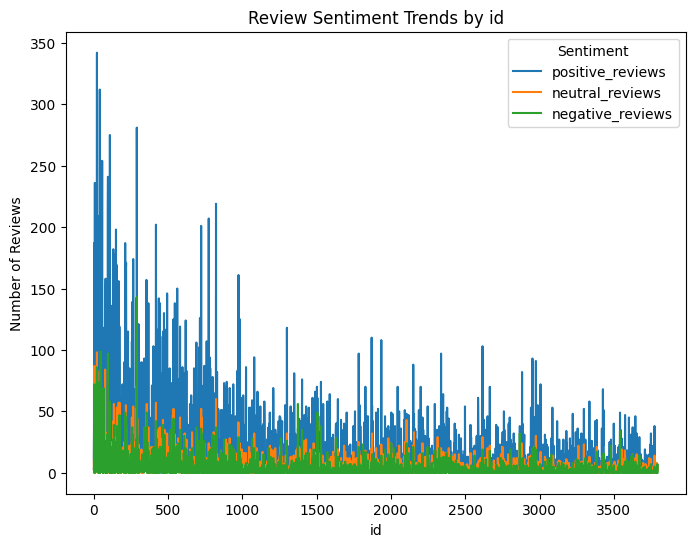

In [116]:
df.plot(x='id', y=['positive_reviews', 'neutral_reviews', 'negative_reviews'], figsize=(8, 6))
plt.title('Review Sentiment Trends by id')
plt.xlabel('id')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.show()



In [117]:
df[df['positive_reviews'] > 300] # settling on horizontal normalisation
df['total_reviews_count'] = df[cols_to_normalize].sum(axis=1) # popularity saved

In [118]:
cols_to_normalize = ['positive_reviews', 'neutral_reviews', 'negative_reviews']
df[cols_to_normalize] = df[cols_to_normalize].div(df[cols_to_normalize].sum(axis=1), axis=0)
print(df[cols_to_normalize].sample(5))

      positive_reviews  neutral_reviews  negative_reviews
921           0.729730         0.189189          0.081081
1347          0.000000         1.000000          0.000000
1391          0.750000         0.250000          0.000000
1678          0.600000         0.200000          0.200000
2032          0.666667         0.000000          0.333333


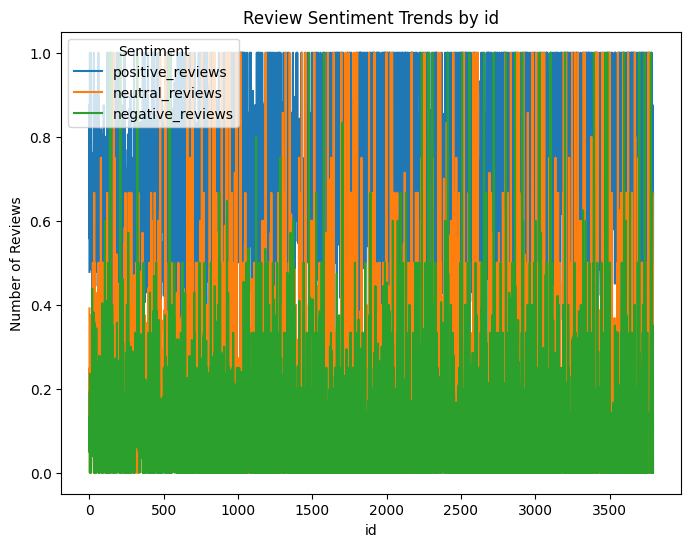

In [119]:
df.plot(x='id', y=['positive_reviews', 'neutral_reviews', 'negative_reviews'], figsize=(8, 6))
plt.title('Review Sentiment Trends by id')
plt.xlabel('id')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.show()



In [133]:
#df['popularity'] = np.log1p(df['total_reviews_count'])
df['popularity'] = (df['total_reviews_count']-df['total_reviews_count'].min())/(df['total_reviews_count'].max()-df['total_reviews_count'].min())

In [142]:
df[df['total_reviews_count']>200].sample(10)

,id,name,brand,gender,positive_reviews,neutral_reviews,negative_reviews,review_texts,fragrance_notes,total_reviews_count,popularity
40,41,Green Irish Tweed,Creed (1985),Unisex,0.697987,0.185682,0.116331,"[""It is very likely this has been reformulated...","lemon, ambergris, iris, violet leaf, verbena, ...",447,0.849524
211,212,Dolce & Gabbana pour Homme,Dolce & Gabbana (1994),Unisex,0.667857,0.157143,0.175000,"[""A nice take on a standard citrusy woody masc...","cedarwood, bergamot, mandarin, sandalwood, lav...",280,0.531429
356,357,Chrome,Azzaro (1996),Male,0.511628,0.260465,0.227907,"[""Refreshing, bracing and citrusy aquatic. Go...","bergamot, sandalwood, rosewood, ivy, bitter or...",215,0.407619
155,156,The Dreamer,Versace (1996),Unisex,0.650000,0.203846,0.146154,"[""modern formulation does nothing for me. its ...","amber, iris, juniper, tobacco, tarragon, lily",260,0.493333
36,37,Le Mâle,Jean Paul Gaultier (1995),Unisex,0.637195,0.137195,0.225610,"[""I have notes on this perfume from a long tim...","orange blossom, vanilla, bergamot, amber, sand...",328,0.622857
973,974,Mugler Cologne,Mugler (2001),Unisex,0.696970,0.177489,0.125541,"[""There's a big grassy neroli in this that ove...","Bergamot, Neroli, Petitgrain, Orange flower, ""...",231,0.438095
33,34,Shalimar,"Eau de Parfum, Guerlain (1925)",Unisex,0.798283,0.085837,0.115880,"[""I really wanted to try this classic so I was...","jasmine, vanilla, patchouli, bergamot, mandari...",233,0.441905
95,96,Kouros,Yves Saint Laurent (1981),Unisex,0.649596,0.088949,0.261456,"[""I was very fortunate to have come across two...","jasmine, patchouli, bergamot, oakmoss, geraniu...",371,0.704762
217,218,Habit Rouge,Guerlain (1965),Unisex,0.684000,0.136000,0.180000,"[""What can be said about Habit Rouge that hasn...","vanilla, patchouli, bergamot, rose, amber, ced...",250,0.474286
108,109,Vetiver,Guerlain (1961),Unisex,0.725594,0.121372,0.153034,"[""i like the drydown the most. the rest is fin...","cedarwood, bergamot, mandarin, coriander, tonk...",379,0.720000


In [141]:
df[df['total_reviews_count']<20].sample(10)

,id,name,brand,gender,positive_reviews,neutral_reviews,negative_reviews,review_texts,fragrance_notes,total_reviews_count,popularity
1849,1850,Guerlinade,Guerlain (1924),Unisex,0.750000,0.250000,0.000000,"[""Opening had a tart zesty lemon with bergamot...","orange blossom, patchouli, rose, orris, tonka ...",8,0.013333
3262,3263,Royall Lyme,Royall Lyme of Bermuda (1957),Male,0.578947,0.315789,0.105263,"[""This one I could never warm up to no matter ...",lime,19,0.034286
278,279,Tobacco Collection Rich Warm Addictive,Zara (2016),Unisex,0.600000,0.100000,0.300000,"[""I blind bought this after a friend told me i...","cedarwood, sandalwood, honey, coconut, tobacco",10,0.017143
2430,2431,1932,"Eau de Parfum, Chanel (2016)",Unisex,1.000000,0.000000,0.000000,"[""I purchased this EDP version (2016) of 1932 ...","jasmine, vanilla, bergamot, rose, sandalwood, ...",3,0.003810
201,202,English Fern,Bronnley,Unisex,0.500000,0.250000,0.250000,"[""English Fern Cologne by Bronnley is a orient...","patchouli, sandalwood, cedar, lavender, fern, ...",4,0.005714
1875,1876,Alain Delon / AD,"Eau de Toilette, Alain Delon (1980)",Male,0.666667,0.200000,0.133333,"[""Alain Delon is a famous French actor who dec...","cedarwood, bergamot, amber, geranium, benzoin,...",15,0.026667
1475,1476,Sir Irisch Moos,Sir (1969),Male,0.846154,0.076923,0.076923,"[""Irisch Moos is okay; I'm not gaga about it a...","patchouli, cedarwood, bergamot, rosemary, gera...",13,0.022857
1313,1314,Vintage Soul by Curve,Liz Claiborne (2006),Male,0.583333,0.416667,0.000000,"[""This is a fragrance I like better and better...","jasmine, vanilla, patchouli, bergamot, musk, a...",12,0.020952
3614,3615,Mortel,Trudon (2017),Unisex,1.000000,0.000000,0.000000,"[""Mortel's incense trades austerity for warmth...","incense, benzoin, black pepper",6,0.009524
3009,3010,Lui,Guerlain (2017),Unisex,0.833333,0.166667,0.000000,"[""I get smoky vanilla. Seems to wear light. Al...","vanilla, musk, woods, clove, leather, benzoin,...",12,0.020952


In [146]:
df['review_texts'] = df['review_texts'].str.strip('[],""')
df['review_texts'] 

0       I felt incredibly disappointed by this scent. ...
1       My wife is a lover of Chypre fragrances starti...
2       What to say about this classic that hasn't alr...
3       I knew I HAD to sample this after reading onli...
4       Generic \"shower gel\" soap smell with terribl...
                              ...                        
3788    It opens with a sweetness that consists of swe...
3789    Just perfect! Happy and simple smell! My fragr...
3790    Another day, another 60s green chypre. Where d...
3791    The opening is a fruity affair, steamed peache...
3792    If I could give this a 3.5, rather than either...
Name: review_texts, Length: 3296, dtype: str

In [ ]:
unique_notes_count = df['fragrance_notes'].str.split(',').explode().str.strip().nunique()
print(unique_notes_count) # curse of dimensionality sitting on my doorstep


3569


## Distillation of fragrance notes

In [170]:
from sentence_transformers import SentenceTransformer
import umap
import hdbscan

In [190]:
unique_notes = df['fragrance_notes'].str.split(',').explode().str.strip().str.lower().unique().tolist()
print(unique_notes)

['pink pepper', 'orange blossom', 'jasmine', 'coffee', 'vanilla', 'patchouli', 'cedarwood', 'bergamot', 'mandarin', 'peach', 'gardenia', 'galbanum', 'hyacinth', 'rose', 'lily of the valley', 'orris', 'oakmoss', 'amber', 'sandalwood', 'rosemary', 'hespiradic notes', 'persimmon fruits', 'marine notes', 'cedar', 'white musk', 'rock rose', 'egyptian cassie', 'pepper flower', 'geranium', 'balsams', 'myrrh', 'lavender', 'coriander', 'peppermint', 'dihydromyrcenol', 'sandalwood.', 'musk', 'tobacco leaf', 'spices', 'tonka bean', 'tobacco flower', 'cocoa', 'dry fruit accord', 'woods', 'blackcurrant', 'lemon', 'orchid', 'spicy notes', 'fruity notes', 'lotus', 'vetiver', 'incense', 'chocolate', 'italian bergamot', 'french apples', 'pineapple', 'dry birch', 'moroccan jasmine', 'ambergris', 'apple', 'violet', 'guaiac wood', 'cardamom', 'pepper', 'raspberry', 'dewberry', 'green tea', 'freesia', 'apple blossom', 'honeysuckle', 'white hibiscus', 'orange flower', 'nutmeg', 'clove', 'ylang ylang', 'iris

In [191]:
# generate embeddings
model = SentenceTransformer('nomic-ai/nomic-embed-text-v1.5', trust_remote_code=True)

embeddings = model.encode(unique_notes, show_progress_bar=True, truncate_dim=64)

print(f"Embedding shape: {embeddings.shape}")
print("Dimension Reduction Commences...")

umap_model = umap.UMAP(
    n_neighbors=12,
    n_components=4,
    metric = 'cosine',
    random_state=40
)
comp_vectors = umap_model.fit_transform(embeddings)

print("Clustering...")

cluster = hdbscan.HDBSCAN(
    min_cluster_size=8, 
    metric='euclidean', 
    core_dist_n_jobs=-1)

cluster_labels = cluster.fit_predict(comp_vectors)

print("Dict creation")
clustering_df = pd.DataFrame({
    'raw_note': unique_notes,
    'cluster_id': cluster_labels
})

valid_cluster = clustering_df[clustering_df['cluster_id']!= -1]

taxonomy_dict = {}
for cluster_id, group in valid_cluster.groupby('cluster_id'):
    parent_name = group.loc[group['raw_note'].str.len().idxmin(), 'raw_note']

    for raw_note in group['raw_note']:
        taxonomy_dict[raw_note] = parent_name
print(f"Successfully created dict with {len(taxonomy_dict)}notes")

# ingesting back in data

print("Changes are now going to be ingested back in data")

def map_notes(note_string):
    if pd.isna(note_string):
        return ""
    raw_notes = [note.strip() for note in note_string.split(',')]

    mapped_notes = [taxonomy_dict[note] for note in raw_notes if note in taxonomy_dict]
    unique_mapped_notes = list(set(mapped_notes))

    return ",".join(unique_mapped_notes)

df['cleaned_notes'] = df['fragrance_notes'].apply(map_notes)
print(df[['fragrance_notes','cleaned_notes']])

<All keys matched successfully>
Batches: 100%|██████████| 101/101 [00:07<00:00, 13.47it/s]
/Users/gauravkumar/Downloads/cologne-recommender/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding shape: (3227, 64)
Dimension Reduction Commences...
Clustering...
Dict creation
Successfully created dict with 2484notes
Changes are now going to be ingested back in data
                                        fragrance_notes  \
0     pink pepper, orange blossom, jasmine, coffee, ...   
1     jasmine, patchouli, bergamot, mandarin, peach,...   
2     jasmine, patchouli, rosemary, hespiradic notes...   
3     pink pepper, jasmine, rose, amber, egyptian ca...   
4     orange blossom, jasmine, oakmoss, amber, sanda...   
...                                                 ...   
3788  Dewy Coral flower, Tiare flower, Frangipani bl...   
3789  freesia, strawberry, coconut, ambrox, italian ...   
3790  bergamot, galbanum, lemon, labdanum, may rose,...   
3791  jasmine, patchouli, mandarin, peach, gardenia,...   
3792  orange blossom, vanilla, cedarwood, mandarin, ...   

                                          cleaned_notes  
0     mocha,cedar,vanilla,chili,orange flower,jasmin.

In [200]:
df.sample(10)

,id,name,brand,gender,positive_reviews,neutral_reviews,negative_reviews,review_texts,fragrance_notes,total_reviews_count,popularity,cleaned_notes
3690,3691,"24, Faubourg Eau Délicate",Hermès (2003),Unisex,0.833333,0.083333,0.083333,"Maternita by Pablo Picasso"", ""This is getting ...","orange blossom, jasmine, vanilla, sandalwood, ...",12,0.020952,"banana,sandal,geranium,vanilla,orange flower,j..."
961,962,La Belle,Jean Paul Gaultier (2019),Unisex,0.666667,0.333333,0.000000,This gives me similar vibes to Kayali Deja Vu ...,"vanilla, vetiver, pear",3,0.003810,"pear,vanilla,vetiver"
192,193,Oscar,Oscar de la Renta (1977),Male,0.694444,0.166667,0.138889,"The starched white, bittersweet Oscar displays...","orange blossom, jasmine, patchouli, cedarwood,...",36,0.066667,"vetiver,benjoin,iris,musk,sap,orange flower,my..."
1624,1625,Explorer Ultra Blue,Montblanc (2021),Unisex,0.142857,0.571429,0.285714,There's not really much to say about Explorer ...,"patchouli, bergamot, woods, leather, marine ac...",7,0.011429,"rain accord,bergamot,woods,mace,benjoin,citrus"
1454,1455,No. 7 Spiced Ginger & Rum,Goodfellow & Co.,Male,0.000000,1.000000,0.000000,Smells great. Lasts about 3 hours on me. Gets ...,"spices, ginger, rum",2,0.001905,"spice,rum,ginger"
2641,2642,Cannabis Rose,Fresh (2009),Unisex,0.750000,0.000000,0.250000,All I can say is congrats to the perfumer Jero...,"jasmine, patchouli, bergamot, white musk, bulg...",4,0.005714,"musk,bergamot,oud accord,milk,tea,jasmine,benj..."
882,883,APOM pour Homme,Maison Francis Kurkdjian (2009),Unisex,0.516129,0.258065,0.225806,phew. Sugared orange blossom. Quite off puttin...,"orange blossom, cedarwood, amber",31,0.057143,"orange flower,amber,cedar"
1184,1185,Dia Man,Amouage (2002),Unisex,0.671233,0.301370,0.027397,"Type casting exists for a reason, for worse or...","patchouli, orris, amber, vetiver, incense, car...",73,0.137143,"ylang,amber,peony,vetiver,gingko,mace,benjoin,..."
2897,2898,Sonia Rykiel,Sonia Rykiel (1997),Male,0.875000,0.000000,0.125000,A nicely blended gourmet oriental that takes m...,"vanilla, patchouli, cedarwood, mandarin, rose,...",8,0.013333,"cedar,vanilla,honey,tonka,currant,gingko,benjo..."
79,80,Mitsouko,"Eau de Parfum, Guerlain",Unisex,0.778325,0.133005,0.088670,The peach note pure genius. The chypre providi...,"jasmine, peach, spicy notes, vetiver, may rose",203,0.384762,"jasmine,vetiver,henna,peach"


In [193]:
unique_notes_count = df['cleaned_notes'].str.split(',').explode().str.strip().nunique()
print(unique_notes_count)

113


In [ ]:
df_cleaned = df[['id', 'name', 'brand', 'gender', 'positive_reviews', 'negative_reviews', 'neutral_reviews', 'review_texts', 'cleaned_notes', 'popularity']]

In [207]:
df_cleaned.sample(5)

,id,name,brand,gender,positive_reviews,negative_reviews,neutral_reviews,review_texts,cleaned_notes,popularity
804,805,Ylang 49,Le Labo (2013),Unisex,0.714286,0.071429,0.214286,"Oh, how I long resisted purchasing anything fr...","ylang,benzoin,sandal,gardenia,vetiver,benjoin",0.024762
2878,2879,Guess Seductive Homme,Guess (2011),Male,0.500000,0.285714,0.214286,There is a lovely warmth in the heart of this ...,"musk,elemi,amber,sandal,orange,chili,vetiver,g...",0.024762
617,618,Princess,Vera Wang (2006),Male,0.619048,0.142857,0.238095,This is my go to fragrance. It has a sweet sce...,,0.078095
1142,1143,Dune pour Homme,"Eau de Toilette, Christian Dior (1997)",Unisex,0.597015,0.223881,0.179104,Dune pour Homme by Christian Dior (1997) was r...,"hedione,sandal,cedar,sage,sap,tonka,currant,mo...",0.125714
3487,3488,Cologne Grand Luxe,Fragonard (2006),Unisex,1.000000,0.000000,0.000000,I\u2019m of the mind that neroli is sweet enou...,"bergamot,neroli,orange,velvet,lemon,tangelo",0.017143


In [208]:
df_cleaned.to_csv('cleaned_data.csv',index=False)